#### 연령별 인구현황 피라미드
- 연령별 인구현황 검색해서 자료 수집

##### 판다스, 맵플롯립, 맵플롯립 한글 설정

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
## 맷플롯립 한글 설정
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['font.size'] = 15
matplotlib.rcParams['axes.unicode_minus'] = False

- 파일 이름 설정

In [13]:
filename = '201601_201601_연령별인구현황_월간.xlsx'

- 남자 데이터 파일 읽어오기(skiprows, usecols, index_col)

In [15]:
df_m = pd.read_excel(filename, skiprows=3, usecols='b, e:y', index_col='행정기관')
df_m.head()

C:\ProgramData\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,0~4세,5~9세,10~14세,15~19세,20~24세,25~29세,30~34세,35~39세,40~44세,45~49세,...,55~59세,60~64세,65~69세,70~74세,75~79세,80~84세,85~89세,90~94세,95~99세,100세 이상
행정기관,,,,,,,,,,,,,,,,,,,,,
전국,"1,155,577","1,206,856","1,269,868","1,696,258","1,884,688","1,641,633","1,902,777","2,008,358","2,233,150","2,277,374",...,"2,031,839","1,424,146","1,058,511","799,513","567,225","291,133","104,773","31,627","7,069","3,832"
서울특별시,"200,437","200,281","214,007","292,742","354,609","367,513","427,894","407,957","429,079","420,928",...,"379,307","281,099","215,133","163,076","103,961","48,818","18,186","5,988","1,781","1,314"
부산광역시,"69,107","68,321","74,000","106,423","130,628","110,048","122,708","129,049","138,324","144,608",...,"154,315","120,314","88,623","64,233","41,545","19,081","6,255","1,733",370,322
대구광역시,"51,628","55,431","63,634","89,147","99,981","79,397","82,404","89,552","104,114","112,145",...,"99,263","70,412","50,774","36,848","25,794","13,261","4,182","1,090",219,120
인천광역시,"68,866","70,417","71,572","95,560","111,748","97,508","113,425","120,552","130,336","130,859",...,"119,223","74,874","52,847","37,063","24,389","12,470","4,668","1,588",386,194
광주광역시,"34,868","39,140","43,168","58,806","59,220","44,364","53,049","57,583","64,238","64,513",...,"50,537","33,690","27,147","19,914","12,990","6,599","2,444",640,107,35
대전광역시,"36,201","38,095","41,072","54,756","59,993","51,892","56,390","58,602","66,116","67,366",...,"57,342","38,814","27,470","19,836","13,308","6,938","2,560",764,187,65
울산광역시,"30,124","29,911","30,699","43,305","48,532","40,540","46,004","48,671","50,300","55,749",...,"48,634","31,593","20,239","12,531","7,484","3,477","1,111",270,70,26
세종특별자치시,"7,721","7,910","6,546","5,720","6,110","5,896","8,874","10,984","11,595","9,013",...,"6,469","4,590","3,282","2,472","1,941","1,082",419,119,13,9


In [4]:
df_m.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18 entries, 전국   to 제주특별자치도  
Data columns (total 21 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   0~4세     18 non-null     object
 1   5~9세     18 non-null     object
 2   10~14세   18 non-null     object
 3   15~19세   18 non-null     object
 4   20~24세   18 non-null     object
 5   25~29세   18 non-null     object
 6   30~34세   18 non-null     object
 7   35~39세   18 non-null     object
 8   40~44세   18 non-null     object
 9   45~49세   18 non-null     object
 10  50~54세   18 non-null     object
 11  55~59세   18 non-null     object
 12  60~64세   18 non-null     object
 13  65~69세   18 non-null     object
 14  70~74세   18 non-null     object
 15  75~79세   18 non-null     object
 16  80~84세   18 non-null     object
 17  85~89세   18 non-null     object
 18  90~94세   18 non-null     object
 19  95~99세   18 non-null     object
 20  100세 이상  18 non-null     object
dtypes: object(21)
memory usage: 3.1+ KB


- 전국 인구 (콤마), 제외하고 숫자로 변환

In [6]:
# 모든 컬럼에 대해 반복하며 콤마(,)를 빈 문자열('')로 바꾸고 숫자로 변환
for col in df_m.columns:
    if df_m[col].dtype == 'object': # 데이터 타입이 문자열인 경우에만
        df_m[col] = df_m[col].str.replace(',', '').astype(int)
df_m

,0~4세,5~9세,10~14세,15~19세,20~24세,25~29세,30~34세,35~39세,40~44세,45~49세,...,55~59세,60~64세,65~69세,70~74세,75~79세,80~84세,85~89세,90~94세,95~99세,100세 이상
행정기관,,,,,,,,,,,,,,,,,,,,,
전국,2252633,2342316,2443333,3247176,3554181,3143066,3713025,3941324,4385464,4484875,...,4062966,2905336,2207657,1782682,1391957,845549,390118,135283,31877,16382
서울특별시,391063,390250,414415,565227,702970,743560,852667,812333,856164,846875,...,788478,589342,455271,346714,236465,131532,62878,23345,6601,5084
부산광역시,134357,132853,142320,201243,244667,211593,240103,252606,275146,293180,...,319604,249808,186207,139677,99950,55211,24632,7863,1751,1497
대구광역시,100782,107073,120454,167685,181729,144935,162093,179522,211564,227121,...,201816,147330,108474,84274,64394,38102,15769,4965,1114,552
인천광역시,134100,137271,138930,184097,213137,188879,220888,234339,254948,261848,...,234500,149924,108203,81469,60746,37136,18007,6476,1555,717
광주광역시,67513,75804,83000,113160,112565,86396,104811,115554,129354,129160,...,103588,70346,57782,44363,32192,19252,9334,3125,758,317
대전광역시,70410,74076,79028,104904,113384,97389,110633,117397,132314,134985,...,115540,78870,56567,43781,32347,20012,9238,3219,727,290
울산광역시,58579,57544,57934,81326,86189,72381,87338,93123,100507,111412,...,94743,61869,39560,26864,18903,11119,5057,1729,348,142
세종특별자치시,14941,15619,12953,11094,11622,11865,18610,22211,21949,16507,...,12608,9158,6798,5640,4769,3212,1556,545,93,38


In [11]:
df_m.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18 entries, 전국   to 제주특별자치도  
Data columns (total 21 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   0~4세     18 non-null     object
 1   5~9세     18 non-null     object
 2   10~14세   18 non-null     object
 3   15~19세   18 non-null     object
 4   20~24세   18 non-null     object
 5   25~29세   18 non-null     object
 6   30~34세   18 non-null     object
 7   35~39세   18 non-null     object
 8   40~44세   18 non-null     object
 9   45~49세   18 non-null     object
 10  50~54세   18 non-null     object
 11  55~59세   18 non-null     object
 12  60~64세   18 non-null     object
 13  65~69세   18 non-null     object
 14  70~74세   18 non-null     object
 15  75~79세   18 non-null     object
 16  80~84세   18 non-null     object
 17  85~89세   18 non-null     object
 18  90~94세   18 non-null     object
 19  95~99세   18 non-null     object
 20  100세 이상  18 non-null     object
dtypes: object(21)
memory usage: 3.1+ KB


In [25]:
df_m.iloc[0]=df_m.iloc[0].str.replace(',','').astype(int)

In [26]:
df_m.iloc[0]

0~4세       1155577
5~9세       1206856
10~14세     1269868
15~19세     1696258
20~24세     1884688
25~29세     1641633
30~34세     1902777
35~39세     2008358
40~44세     2233150
45~49세     2277374
50~54세     2167030
55~59세     2031839
60~64세     1424146
65~69세     1058511
70~74세      799513
75~79세      567225
80~84세      291133
85~89세      104773
90~94세       31627
95~99세        7069
100세 이상       3832
Name: 전국  , dtype: object

- 여자 데이터 파일 읽어오기

In [16]:
df_w = pd.read_excel(filename, skiprows=3, usecols='b, ab:av', index_col='행정기관')
df_w.head(3)

C:\ProgramData\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,0~4세.1,5~9세.1,10~14세.1,15~19세.1,20~24세.1,25~29세.1,30~34세.1,35~39세.1,40~44세.1,45~49세.1,...,55~59세.1,60~64세.1,65~69세.1,70~74세.1,75~79세.1,80~84세.1,85~89세.1,90~94세.1,95~99세.1,100세 이상.1
행정기관,,,,,,,,,,,,,,,,,,,,,
전국,"1,097,056","1,135,460","1,173,465","1,550,918","1,669,493","1,501,433","1,810,248","1,932,966","2,152,314","2,207,501",...,"2,031,127","1,481,190","1,149,146","983,169","824,732","554,416","285,345","103,656","24,808","12,550"
서울특별시,"190,626","189,969","200,408","272,485","348,361","376,047","424,773","404,376","427,085","425,947",...,"409,171","308,243","240,138","183,638","132,504","82,714","44,692","17,357","4,820","3,770"
부산광역시,"65,250","64,532","68,320","94,820","114,039","101,545","117,395","123,557","136,822","148,572",...,"165,289","129,494","97,584","75,444","58,405","36,130","18,377","6,130","1,381","1,175"
대구광역시,"49,154","51,642","56,820","78,538","81,748","65,538","79,689","89,970","107,450","114,976",...,"102,553","76,918","57,700","47,426","38,600","24,841","11,587","3,875",895,432
인천광역시,"65,234","66,854","67,358","88,537","101,389","91,371","107,463","113,787","124,612","130,989",...,"115,277","75,050","55,356","44,406","36,357","24,666","13,339","4,888","1,169",523
광주광역시,"32,645","36,664","39,832","54,354","53,345","42,032","51,762","57,971","65,116","64,647",...,"53,051","36,656","30,635","24,449","19,202","12,653","6,890","2,485",651,282
대전광역시,"34,209","35,981","37,956","50,148","53,391","45,497","54,243","58,795","66,198","67,619",...,"58,198","40,056","29,097","23,945","19,039","13,074","6,678","2,455",540,225
울산광역시,"28,455","27,633","27,235","38,021","37,657","31,841","41,334","44,452","50,207","55,663",...,"46,109","30,276","19,321","14,333","11,419","7,642","3,946","1,459",278,116
세종특별자치시,"7,220","7,709","6,407","5,374","5,512","5,969","9,736","11,227","10,354","7,494",...,"6,139","4,568","3,516","3,168","2,828","2,130","1,137",426,80,29


- 남자 데이터와 여자 데이터 컬럼명 일치시키기

In [17]:
df_w.columns = df_m.columns

In [18]:
df_w.columns

Index(['0~4세', '5~9세', '10~14세', '15~19세', '20~24세', '25~29세', '30~34세',
       '35~39세', '40~44세', '45~49세', '50~54세', '55~59세', '60~64세', '65~69세',
       '70~74세', '75~79세', '80~84세', '85~89세', '90~94세', '95~99세', '100세 이상'],
      dtype='object')

In [19]:
df_w.head(3)

,0~4세,5~9세,10~14세,15~19세,20~24세,25~29세,30~34세,35~39세,40~44세,45~49세,...,55~59세,60~64세,65~69세,70~74세,75~79세,80~84세,85~89세,90~94세,95~99세,100세 이상
행정기관,,,,,,,,,,,,,,,,,,,,,
전국,"1,097,056","1,135,460","1,173,465","1,550,918","1,669,493","1,501,433","1,810,248","1,932,966","2,152,314","2,207,501",...,"2,031,127","1,481,190","1,149,146","983,169","824,732","554,416","285,345","103,656","24,808","12,550"
서울특별시,"190,626","189,969","200,408","272,485","348,361","376,047","424,773","404,376","427,085","425,947",...,"409,171","308,243","240,138","183,638","132,504","82,714","44,692","17,357","4,820","3,770"
부산광역시,"65,250","64,532","68,320","94,820","114,039","101,545","117,395","123,557","136,822","148,572",...,"165,289","129,494","97,584","75,444","58,405","36,130","18,377","6,130","1,381","1,175"


- 전국 인구 (콤마), 제외하고 숫자로 변환

In [29]:
df_w.iloc[0]=df_w.iloc[0].str.replace(',','').astype(int)

AttributeError: Can only use .str accessor with string values!

In [30]:
df_w.iloc[0]

0~4세       1097056
5~9세       1135460
10~14세     1173465
15~19세     1550918
20~24세     1669493
25~29세     1501433
30~34세     1810248
35~39세     1932966
40~44세     2152314
45~49세     2207501
50~54세     2097352
55~59세     2031127
60~64세     1481190
65~69세     1149146
70~74세      983169
75~79세      824732
80~84세      554416
85~89세      285345
90~94세      103656
95~99세       24808
100세 이상      12550
Name: 전국  , dtype: object

- 인구 피라미드 시각화, 크기( 15, 9 ), barh, 제목(2016년 인구 피라미드), png 파일 저장

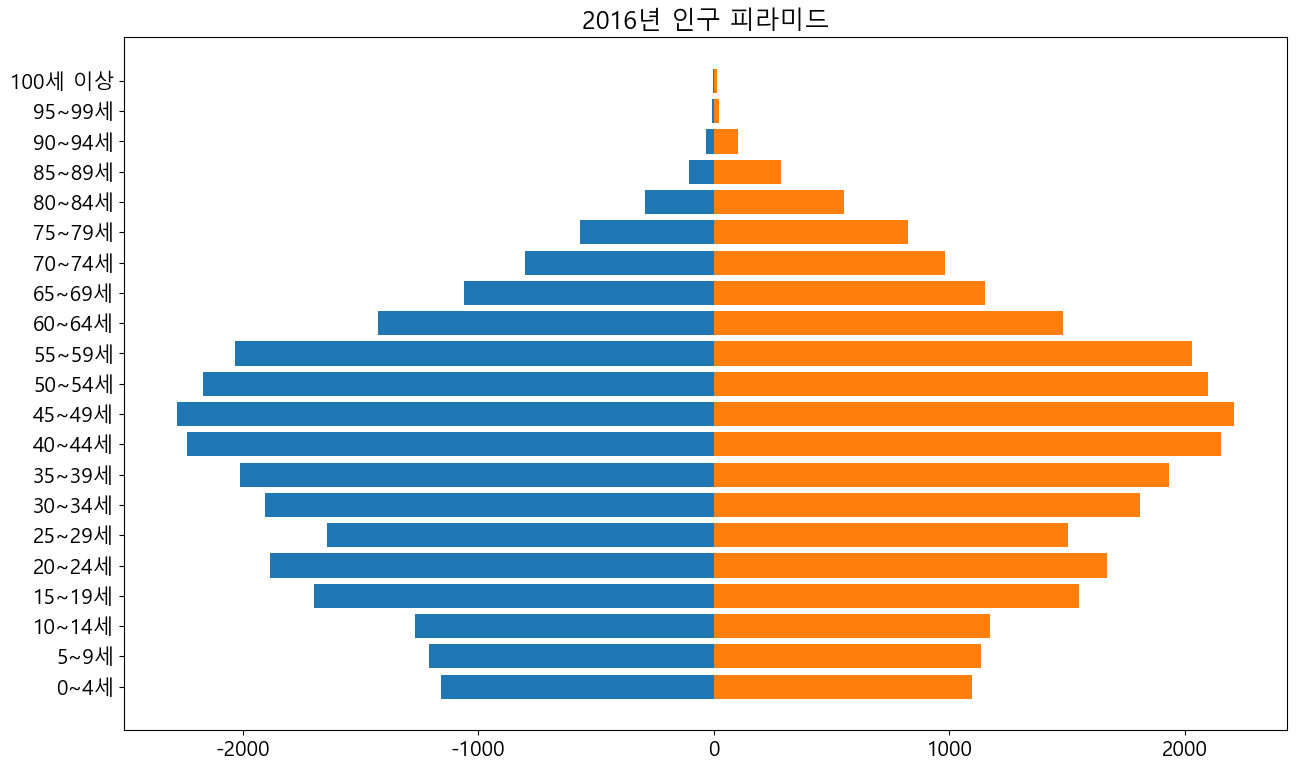

In [37]:
plt.figure(figsize=(15,9))
plt.barh(df_m.columns, -df_m.iloc[0] // 1000)
plt.barh(df_w.columns, df_w.iloc[0] // 1000)
plt.title('2016년 인구 피라미드')
plt.savefig('2016년 인구 피라미드.png', dpi=100)
plt.show()

- 2026년 인구 통계 분석

- 파일 이름 설정

In [40]:
filename = '202601_202601_연령별인구현황_월간.xlsx'

In [41]:
df2026_m = pd.read_excel(filename, skiprows=3, usecols='b, e:y', index_col='행정기관')
df2026_m.iloc[0]=df2026_m.iloc[0].str.replace(',','').astype(int)
df2026_w = pd.read_excel(filename, skiprows=3, usecols='b, ab:av', index_col='행정기관')
df2026_w.columns = df2026_m.columns
df2026_w.iloc[0]=df2026_w.iloc[0].str.replace(',','').astype(int)

C:\ProgramData\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


- 위에서 작업한 내용 종합해서 2026년 인구 피라미드 작성

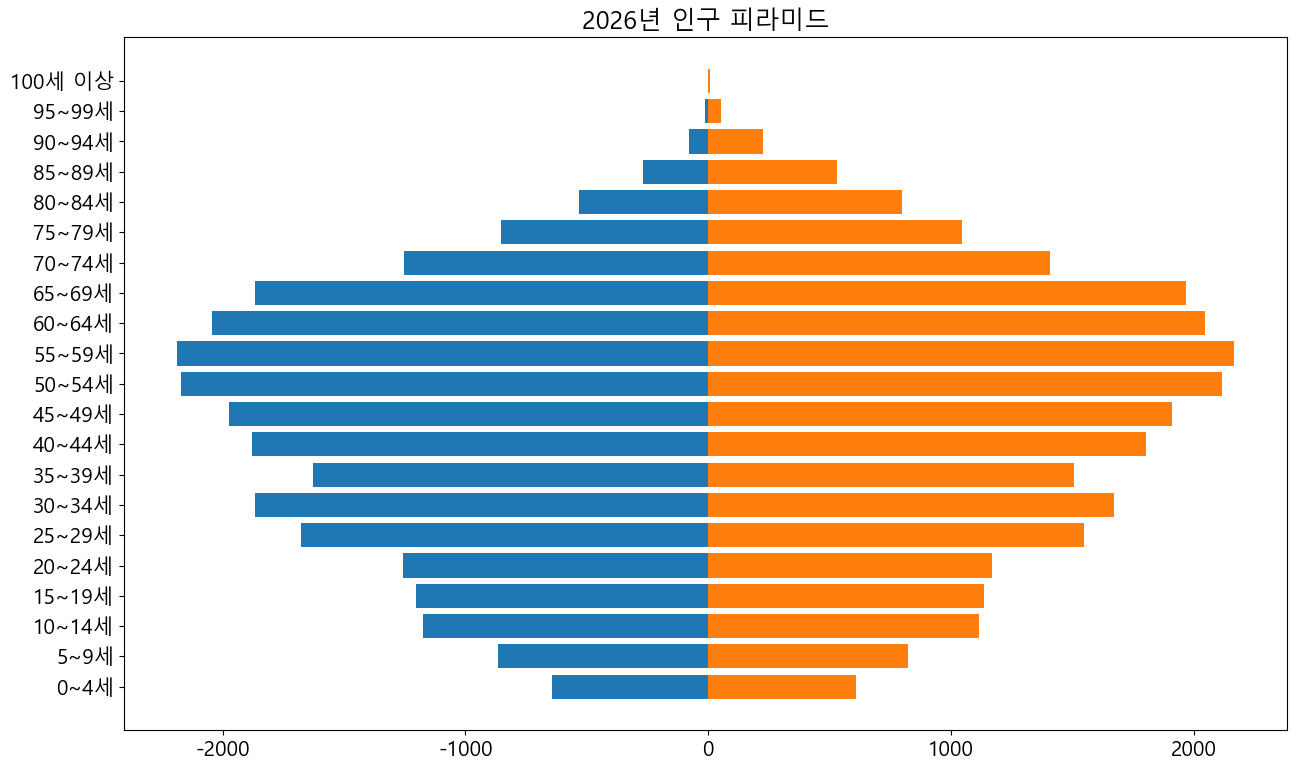

In [46]:
plt.figure(figsize=(15,9))
plt.barh(df2026_m.columns, -df2026_m.iloc[0] // 1000)
plt.barh(df2026_w.columns, df2026_w.iloc[0] // 1000)
plt.title('2026년 인구 피라미드')
plt.savefig('2026년 인구 피라미드.png', dpi=100)
plt.show()

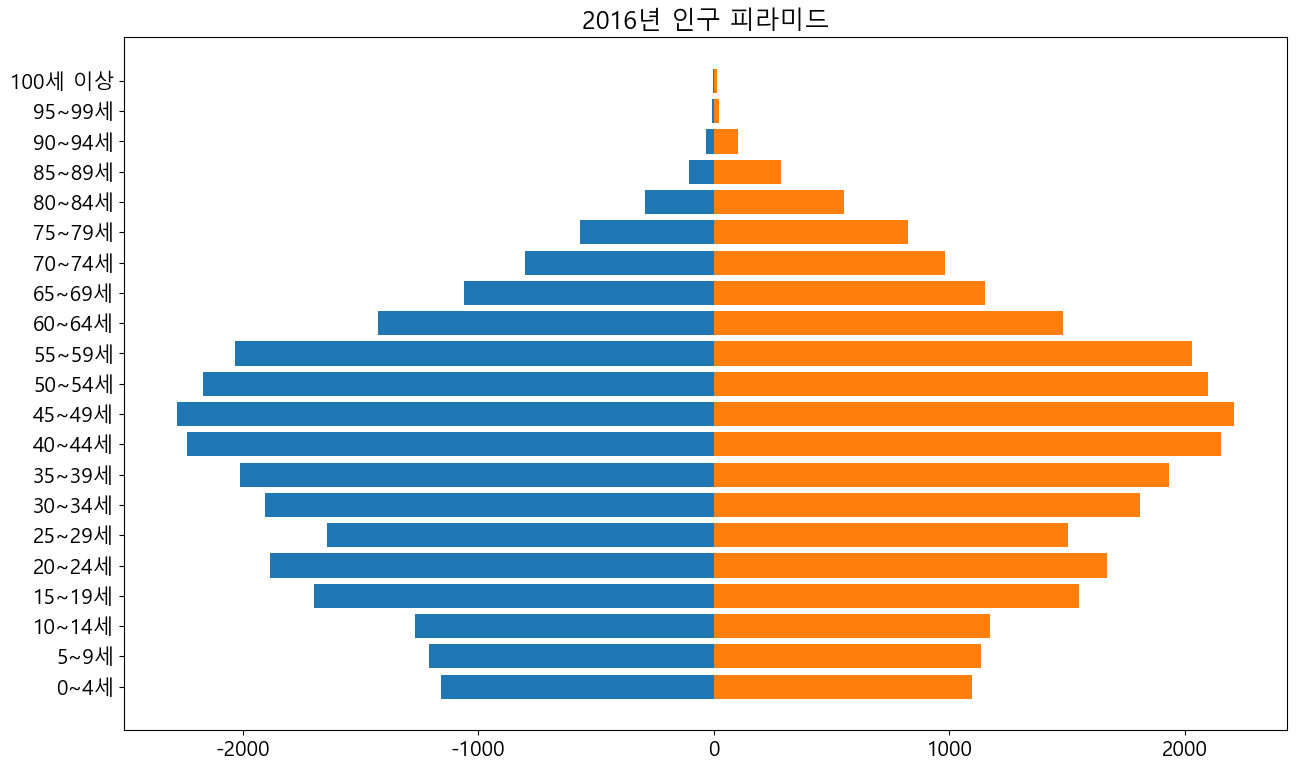

In [47]:
plt.figure(figsize=(15,9))
plt.barh(df_m.columns, -df_m.iloc[0] // 1000)
plt.barh(df_w.columns, df_w.iloc[0] // 1000)
plt.title('2016년 인구 피라미드')
plt.savefig('2016년 인구 피라미드.png', dpi=100)
plt.show()